# Channel Ablation (Scratch Baseline)

В этом ноутбуке проводится анализ влияния количества ЭЭГ-каналов на качество модели в задаче классификации P300. Сравниваются результаты обучения с нуля (scratch) для трёх наборов каналов (14, 7 и 3) на benchmark-выборке BigP3BCI.

Цель — определить, можно ли сократить число каналов без существенной потери качества модели.

## Импорты и загрузки

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import seaborn as sns

### Отдельные таблицы

In [ ]:
# from pathlib import Path
# import pandas as pd

# # корень проекта
# ROOT = Path.cwd().parents[2]

# # пути к таблицам
# PATH_CH3 = ROOT / "outputs" / "downstream" / "channel_ablation" / "ch3" / "tables" / "Scratch_summary.csv"
# PATH_CH7 = ROOT / "outputs" / "downstream" / "channel_ablation" / "ch7" / "tables" / "Scratch_summary.csv"
# PATH_CH14 = ROOT / "outputs" / "downstream" / "test" / "tables" / "Scratch_summary.csv"

# print("CH3:", PATH_CH3)
# print("CH7:", PATH_CH7)
# print("CH14:", PATH_CH14)

# # загрузка
# df_ch3 = pd.read_csv(PATH_CH3)
# df_ch7 = pd.read_csv(PATH_CH7)
# df_ch14 = pd.read_csv(PATH_CH14)
# df_ch14["channel_set"] = "ch14"
# df_ch14["n_channels"] = 14

# # быстрый чек
# print(df_ch3.shape, df_ch7.shape, df_ch14.shape)

CH3: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\channel_ablation\ch3\tables\Scratch_summary.csv
CH7: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\channel_ablation\ch7\tables\Scratch_summary.csv
CH14: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\tables\Scratch_summary.csv
(366, 36) (366, 36) (366, 35)


### Объединённая таблица

In [2]:
# корень проекта
ROOT = Path.cwd().parents[2]

# пути к таблицам
PATH_DF_ALL = ROOT / "outputs" / "downstream" / "channel_ablation" / "all" / "tables" / "df_all_clean.csv"


# загрузка
df_all= pd.read_csv(PATH_DF_ALL)

# быстрый чек
print(df_all.shape)

(915, 9)


### Пути для сохранения

In [3]:
SAVE_PATH = ROOT / "outputs" / "downstream" / "channel_ablation" / "all" 
SAVE_FIG = SAVE_PATH / "figures"
SAVE_TAB = SAVE_PATH / "tables"

## Объединение таблиц

In [ ]:
# df_all = pd.concat([df_ch14, df_ch7, df_ch3], ignore_index=True)

In [ ]:
# cols = [
#     "subject_id", "p", "channel_set",
#     "auc", "f1", "accuracy",
#     "precision", "recall", "fdr"
# ]

# df_all = df_all[cols]

# # убираем p=0
# df_all = df_all[df_all["p"] > 0].reset_index(drop=True)

In [4]:
# print(df_all.shape)
# print(df_all.memory_usage(deep=True).sum() / 1024**2, "MB")
# print(df_all.columns.tolist())

(915, 9)
0.158355712890625 MB
['subject_id', 'p', 'channel_set', 'auc', 'f1', 'accuracy', 'precision', 'recall', 'fdr']


### Сохранение объединённых таблиц

In [ ]:
# SAVE_PATH = ROOT / "outputs" / "downstream" / "channel_ablation" / "all" / "tables" / "df_all_clean.csv"
# SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

# df_all.to_csv(SAVE_PATH, index=False)

# print("Saved to:", SAVE_PATH)

Saved to: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\channel_ablation\all\tables\df_all_clean.csv


### Агрегация метрик

In [4]:
summary = (
    df_all
    .groupby(["channel_set", "p"], as_index=False)
    .agg(
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        n=("subject_id", "nunique"),
    )
)

summary = summary.sort_values(["p", "channel_set"])

display(summary)

,channel_set,p,mean_auc,std_auc,mean_f1,std_f1,n
0,ch14,10,0.514482,0.055485,0.230198,0.082052,61
5,ch3,10,0.513881,0.056230,0.229691,0.081053,61
10,ch7,10,0.511520,0.053292,0.231044,0.086347,61
1,ch14,20,0.523237,0.056360,0.228651,0.080279,61
6,ch3,20,0.523346,0.054912,0.227290,0.081441,61
11,ch7,20,0.518964,0.063764,0.230732,0.083904,61
2,ch14,40,0.535659,0.058937,0.231175,0.083104,61
7,ch3,40,0.536090,0.067832,0.229570,0.089496,61
12,ch7,40,0.539704,0.081209,0.238771,0.100133,61
3,ch14,60,0.541574,0.058609,0.231289,0.082884,61


In [5]:
summary.groupby("channel_set")["n"].unique()

channel_set
ch14    [61]
ch3     [61]
ch7     [61]
Name: n, dtype: object

## Графики

In [6]:
CHANNEL_LABELS = {
    "ch14": "14 каналов",
    "ch7": "7 каналов",
    "ch3": "3 канала",
}

COLORS = {
    "ch14": "black",
    "ch7": "#e377c2",
    "ch3": "#9467bd",
}

P_ORDER = [10, 20, 40, 60, 100]
CHANNEL_ORDER = ["ch14", "ch7", "ch3"]


def plot_metric_vs_p(
    summary,
    mean_col,
    std_col,
    ylabel,
    title,
    save_path=None,
):
    plt.figure(figsize=(8, 5))

    for ch in CHANNEL_ORDER:
        sub = (
            summary[summary["channel_set"] == ch]
            .sort_values("p")
        )

        sub = sub[sub["p"].isin(P_ORDER)]

        plt.errorbar(
            sub["p"],
            sub[mean_col],
            yerr=sub[std_col],
            marker="o",
            capsize=4,
            linewidth=2,
            label=CHANNEL_LABELS[ch],
            color=COLORS[ch],
        )

    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(P_ORDER)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Набор каналов")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

### График AUC vs p

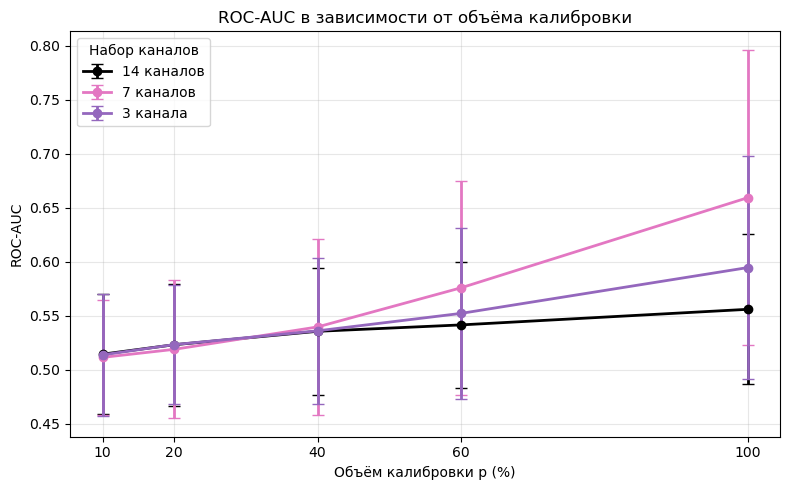

In [ ]:
save_path = SAVE_FIG / 'auc_vs_p'

plot_metric_vs_p(
    summary=summary,
    mean_col="mean_auc",
    std_col="std_auc",
    ylabel="ROC-AUC",
    title="ROC-AUC в зависимости от объёма калибровки",
    save_path = save_path
)

### График F1 vs p

<!--  -->

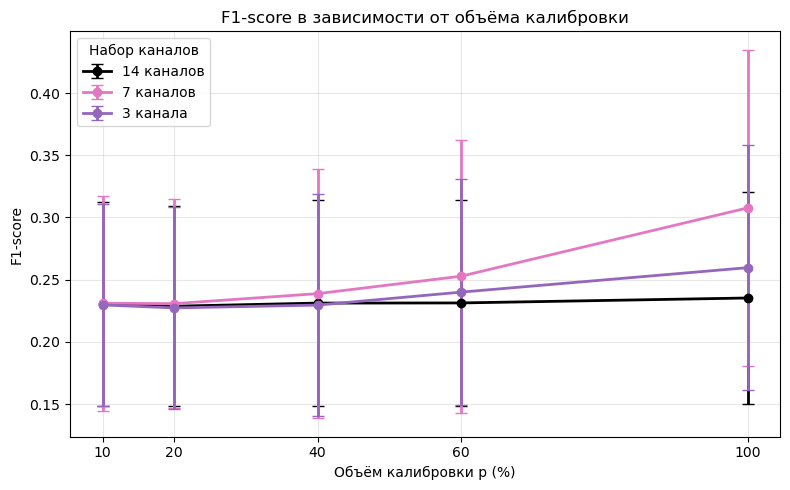

In [ ]:
save_path = SAVE_FIG / 'f1_vs_p'

plot_metric_vs_p(
    summary=summary,
    mean_col="mean_f1",
    std_col="std_f1",
    ylabel="F1-score",
    title="F1-score в зависимости от объёма калибровки",
    save_path=save_path
)

## Δ-анализ относительно baseline (ch14)

### Построение таблицы Δ

In [7]:
# baseline (ch14)
df_base = df_all[df_all["channel_set"] == "ch14"].copy()

# объединяем с остальными
df_delta = df_all.merge(
    df_base,
    on=["subject_id", "p"],
    suffixes=("", "_ch14"),
)

# считаем дельты
df_delta["delta_auc"] = df_delta["auc"] - df_delta["auc_ch14"]
df_delta["delta_f1"] = df_delta["f1"] - df_delta["f1_ch14"]

# убираем сам baseline (он всегда 0)
df_delta = df_delta[df_delta["channel_set"] != "ch14"].copy()

display(df_delta.head())

,subject_id,p,channel_set,auc,f1,accuracy,precision,recall,fdr,channel_set_ch14,auc_ch14,f1_ch14,accuracy_ch14,precision_ch14,recall_ch14,fdr_ch14,delta_auc,delta_f1
305,subj_051,10,ch7,0.502426,0.210456,0.117603,0.117603,1.000000,9.898058e-07,ch14,0.550267,0.217163,0.330337,0.125888,0.789809,0.021560,-0.047841,-0.006707
306,subj_051,20,ch7,0.557633,0.210456,0.117603,0.117603,1.000000,1.260512e-02,ch14,0.547048,0.213281,0.245693,0.121549,0.869427,0.018001,0.010586,-0.002825
307,subj_051,40,ch7,0.509396,0.205128,0.303371,0.118460,0.764331,1.850263e-05,ch14,0.563142,0.213539,0.351685,0.124536,0.748408,0.032400,-0.053746,-0.008411
308,subj_051,60,ch7,0.596485,0.213160,0.140075,0.119432,0.990446,3.723525e-02,ch14,0.551749,0.210456,0.117603,0.117603,1.000000,0.008633,0.044736,0.002704
309,subj_051,100,ch7,0.791597,0.386343,0.744195,0.269086,0.684713,6.798146e-01,ch14,0.538567,0.210456,0.117603,0.117603,1.000000,0.006254,0.253031,0.175887


### Агрегация Δ

In [8]:
delta_summary = (
    df_delta
    .groupby(["channel_set", "p"], as_index=False)
    .agg(
        mean_delta_auc=("delta_auc", "mean"),
        std_delta_auc=("delta_auc", "std"),
        median_delta_auc=("delta_auc", "median"),
        frac_ge_0_auc=("delta_auc", lambda x: (x >= 0).mean()),

        mean_delta_f1=("delta_f1", "mean"),
        std_delta_f1=("delta_f1", "std"),
        median_delta_f1=("delta_f1", "median"),
        frac_ge_0_f1=("delta_f1", lambda x: (x >= 0).mean()),
    )
)

display(delta_summary)

,channel_set,p,mean_delta_auc,std_delta_auc,median_delta_auc,frac_ge_0_auc,mean_delta_f1,std_delta_f1,median_delta_f1,frac_ge_0_f1
0,ch3,10,-0.000601,0.041333,0.003324,0.573770,-0.000507,0.008360,0.000000,0.836066
1,ch3,20,0.000108,0.039163,0.003193,0.524590,-0.001361,0.018538,0.000000,0.688525
2,ch3,40,0.000431,0.039631,0.003441,0.508197,-0.001605,0.016225,-0.000424,0.426230
3,ch3,60,0.010655,0.046976,0.004422,0.557377,0.008682,0.033651,0.001529,0.721311
4,ch3,100,0.038622,0.080480,0.012643,0.672131,0.024376,0.042495,0.004974,0.704918
5,ch7,10,-0.002961,0.043765,-0.000395,0.491803,0.000846,0.012066,0.000000,0.819672
6,ch7,20,-0.004273,0.038618,-0.003720,0.442623,0.002081,0.016647,0.000000,0.672131
7,ch7,40,0.004045,0.048167,0.001890,0.524590,0.007596,0.050466,0.000417,0.606557
8,ch7,60,0.034337,0.067491,0.010123,0.721311,0.021479,0.070549,0.001235,0.721311
9,ch7,100,0.103304,0.118922,0.086908,0.803279,0.072429,0.097077,0.025760,0.885246


### График ΔAUC vs p

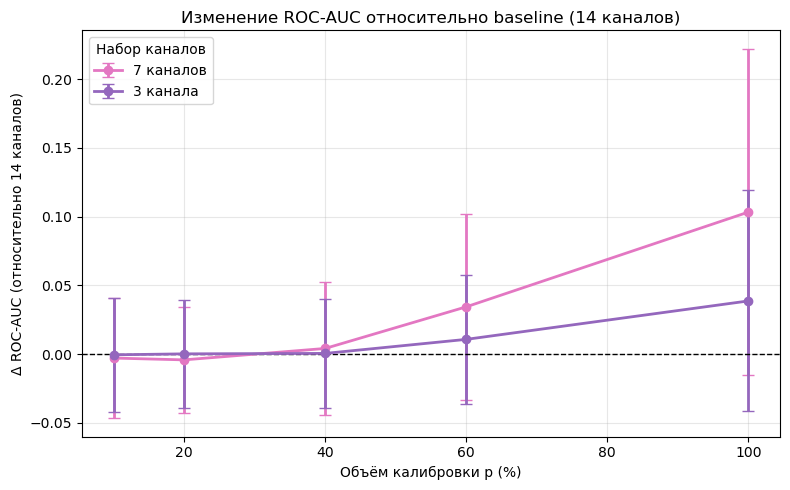

In [ ]:
plt.figure(figsize=(8, 5))

for ch in ["ch7", "ch3"]:
    sub = delta_summary[delta_summary["channel_set"] == ch]

    plt.errorbar(
        sub["p"],
        sub["mean_delta_auc"],
        yerr=sub["std_delta_auc"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=CHANNEL_LABELS[ch],
        color=COLORS[ch],
    )

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.xlabel("Объём калибровки p (%)")
plt.ylabel("Δ ROC-AUC (относительно 14 каналов)")
plt.title("Изменение ROC-AUC относительно baseline (14 каналов)")
plt.legend(title="Набор каналов")
plt.grid(True, alpha=0.3)

plt.tight_layout()

save_path = SAVE_FIG / "delta_auc_vs_ch14"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

### График ΔF1 vs p

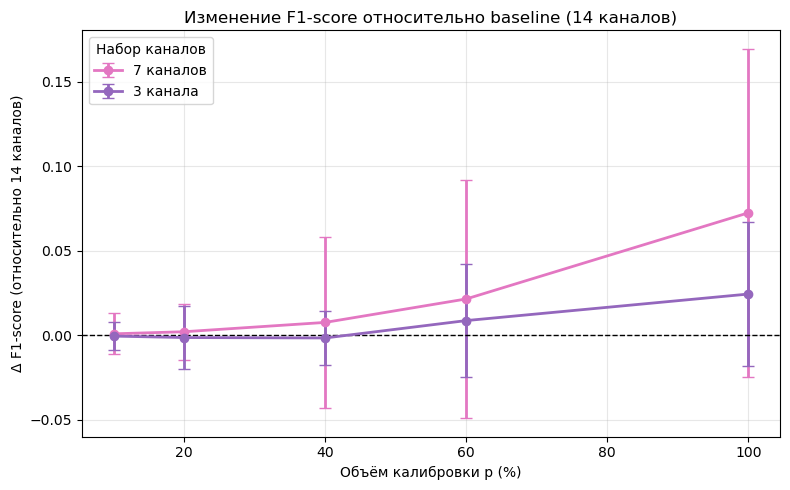

In [ ]:
plt.figure(figsize=(8, 5))

for ch in ["ch7", "ch3"]:
    sub = delta_summary[delta_summary["channel_set"] == ch]

    plt.errorbar(
        sub["p"],
        sub["mean_delta_f1"],
        yerr=sub["std_delta_f1"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=CHANNEL_LABELS[ch],
        color=COLORS[ch],
    )

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.xlabel("Объём калибровки p (%)")
plt.ylabel("Δ F1-score (относительно 14 каналов)")
plt.title("Изменение F1-score относительно baseline (14 каналов)")
plt.legend(title="Набор каналов")
plt.grid(True, alpha=0.3)

plt.tight_layout()

save_path = SAVE_FIG / "delta_f1_vs_ch14"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

### Boxplot ΔAUC (по p)

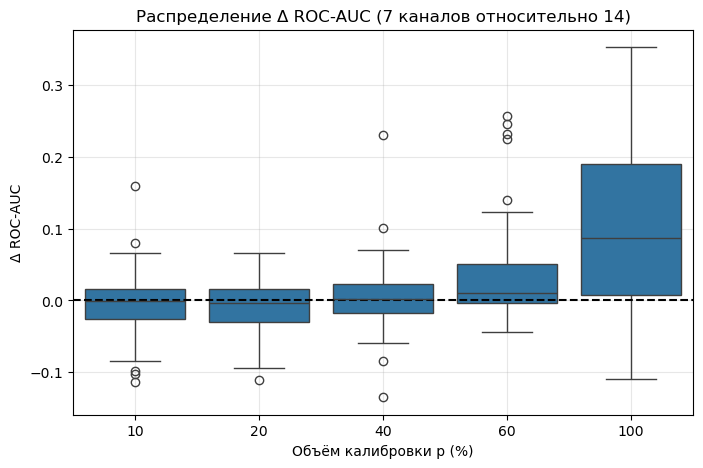

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_delta[df_delta["channel_set"] == "ch7"],
    x="p",
    y="delta_auc"
)

plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Объём калибровки p (%)")
plt.ylabel("Δ ROC-AUC")
plt.title("Распределение Δ ROC-AUC (7 каналов относительно 14)")
plt.grid(True, alpha=0.3)

save_path = SAVE_FIG / "delta_auc_boxplot_ch7_vs_ch14"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

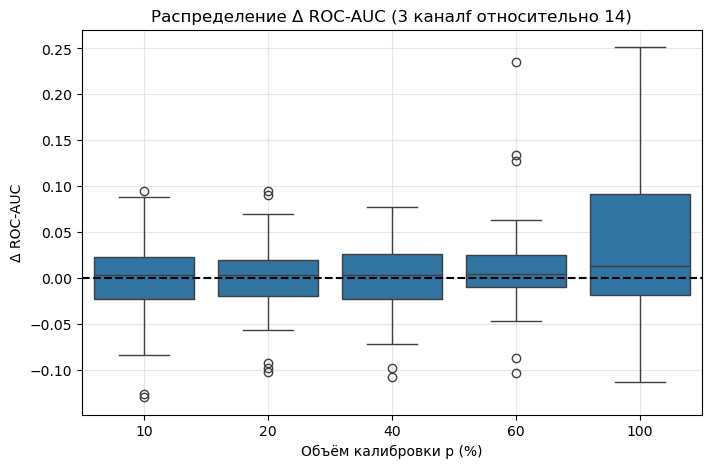

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_delta[df_delta["channel_set"] == "ch3"],
    x="p",
    y="delta_auc"
)

plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Объём калибровки p (%)")
plt.ylabel("Δ ROC-AUC")
plt.title("Распределение Δ ROC-AUC (3 каналf относительно 14)")
plt.grid(True, alpha=0.3)

save_path = SAVE_FIG / "delta_auc_boxplot_ch3_vs_ch14"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

## Статистические тесты (Δ относительно ch14)

In [9]:
def compute_stats(x):
    x = np.array(x)

    mean_diff = x.mean()
    median_diff = np.median(x)
    frac_ge_0 = (x >= 0).mean()

    # Wilcoxon (убираем нули, иначе падает)
    x_nonzero = x[x != 0]

    if len(x_nonzero) < 5:
        p_value = np.nan
    else:
        try:
            _, p_value = wilcoxon(x_nonzero)
        except:
            p_value = np.nan

    return mean_diff, median_diff, frac_ge_0, p_value

In [10]:
rows = []

for ch in ["ch7", "ch3"]:
    for p in sorted(df_delta["p"].unique()):
        sub = df_delta[
            (df_delta["channel_set"] == ch) &
            (df_delta["p"] == p)
        ]

        delta_auc = sub["delta_auc"].values
        delta_f1 = sub["delta_f1"].values

        mean_auc, median_auc, frac_auc, p_auc = compute_stats(delta_auc)
        mean_f1, median_f1, frac_f1, p_f1 = compute_stats(delta_f1)

        rows.append({
            "channel_set": ch,
            "p": p,

            "mean_diff_auc": mean_auc,
            "median_diff_auc": median_auc,
            "frac_ge_0_auc": frac_auc,
            "p_value_auc": p_auc,

            "mean_diff_f1": mean_f1,
            "median_diff_f1": median_f1,
            "frac_ge_0_f1": frac_f1,
            "p_value_f1": p_f1,
        })

stats_df = pd.DataFrame(rows)
display(stats_df)

,channel_set,p,mean_diff_auc,median_diff_auc,frac_ge_0_auc,p_value_auc,mean_diff_f1,median_diff_f1,frac_ge_0_f1,p_value_f1
0,ch7,10,-0.002961,-0.000395,0.491803,5.826745e-01,0.000846,0.000000,0.819672,9.789153e-01
1,ch7,20,-0.004273,-0.003720,0.442623,5.064300e-01,0.002081,0.000000,0.672131,8.583654e-01
2,ch7,40,0.004045,0.001890,0.524590,5.975451e-01,0.007596,0.000417,0.606557,1.766827e-01
3,ch7,60,0.034337,0.010123,0.721311,1.903793e-04,0.021479,0.001235,0.721311,9.334472e-04
4,ch7,100,0.103304,0.086908,0.803279,1.044278e-07,0.072429,0.025760,0.885246,1.574786e-09
5,ch3,10,-0.000601,0.003324,0.573770,6.691061e-01,-0.000507,0.000000,0.836066,8.531995e-01
6,ch3,20,0.000108,0.003193,0.524590,9.455975e-01,-0.001361,0.000000,0.688525,5.706636e-01
7,ch3,40,0.000431,0.003441,0.508197,8.154196e-01,-0.001605,-0.000424,0.426230,2.796937e-01
8,ch3,60,0.010655,0.004422,0.557377,9.073301e-02,0.008682,0.001529,0.721311,2.450282e-02
9,ch3,100,0.038622,0.012643,0.672131,3.422697e-03,0.024376,0.004974,0.704918,1.773036e-05


In [11]:
# Поправка на множественное сравнение
from statsmodels.stats.multitest import multipletests

for metric in ["auc", "f1"]:
    pvals = stats_df[f"p_value_{metric}"].values

    mask = ~np.isnan(pvals)

    adj = np.full_like(pvals, np.nan, dtype=float)

    if mask.sum() > 0:
        adj_vals = multipletests(pvals[mask], method="fdr_bh")[1]
        adj[mask] = adj_vals

    stats_df[f"p_adj_{metric}"] = adj
    stats_df[f"significant_{metric}"] = stats_df[f"p_adj_{metric}"] < 0.05

display(stats_df)

,channel_set,p,mean_diff_auc,median_diff_auc,frac_ge_0_auc,p_value_auc,mean_diff_f1,median_diff_f1,frac_ge_0_f1,p_value_f1,p_adj_auc,significant_auc,p_adj_f1,significant_f1
0,ch7,10,-0.002961,-0.000395,0.491803,5.826745e-01,0.000846,0.000000,0.819672,9.789153e-01,0.836383,False,9.789153e-01,False
1,ch7,20,-0.004273,-0.003720,0.442623,5.064300e-01,0.002081,0.000000,0.672131,8.583654e-01,0.836383,False,9.537394e-01,False
2,ch7,40,0.004045,0.001890,0.524590,5.975451e-01,0.007596,0.000417,0.606557,1.766827e-01,0.836383,False,3.533654e-01,False
3,ch7,60,0.034337,0.010123,0.721311,1.903793e-04,0.021479,0.001235,0.721311,9.334472e-04,0.000952,True,3.111491e-03,True
4,ch7,100,0.103304,0.086908,0.803279,1.044278e-07,0.072429,0.025760,0.885246,1.574786e-09,0.000001,True,1.574786e-08,True
5,ch3,10,-0.000601,0.003324,0.573770,6.691061e-01,-0.000507,0.000000,0.836066,8.531995e-01,0.836383,False,9.537394e-01,False
6,ch3,20,0.000108,0.003193,0.524590,9.455975e-01,-0.001361,0.000000,0.688525,5.706636e-01,0.945597,False,8.152337e-01,False
7,ch3,40,0.000431,0.003441,0.508197,8.154196e-01,-0.001605,-0.000424,0.426230,2.796937e-01,0.906022,False,4.661561e-01,False
8,ch3,60,0.010655,0.004422,0.557377,9.073301e-02,0.008682,0.001529,0.721311,2.450282e-02,0.226833,False,6.125705e-02,False
9,ch3,100,0.038622,0.012643,0.672131,3.422697e-03,0.024376,0.004974,0.704918,1.773036e-05,0.011409,True,8.865182e-05,True


### График с отметкой значимости

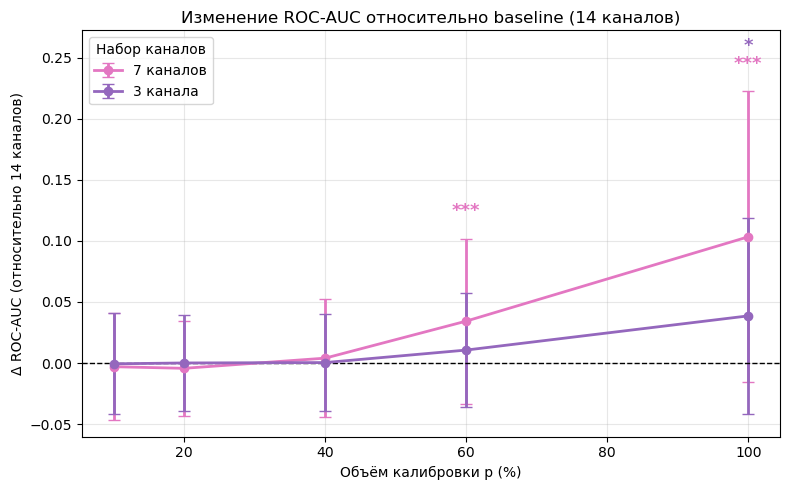

In [17]:
plt.figure(figsize=(8, 5))

def p_to_stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# --- сначала строим линии ---
for ch in ["ch7", "ch3"]:
    sub_plot = delta_summary[delta_summary["channel_set"] == ch]

    plt.errorbar(
        sub_plot["p"],
        sub_plot["mean_delta_auc"],
        yerr=sub_plot["std_delta_auc"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=CHANNEL_LABELS[ch],
        color=COLORS[ch],
    )

# --- добавляем значимость ---
p_values = sorted(delta_summary["p"].unique())

for p_val in p_values:

    # максимум "усиков" среди каналов
    ymax = -np.inf

    for ch in ["ch7", "ch3"]:
        sub_plot = delta_summary[
            (delta_summary["channel_set"] == ch) &
            (delta_summary["p"] == p_val)
        ]

        if len(sub_plot) == 0:
            continue

        mean = sub_plot["mean_delta_auc"].values[0]
        std = sub_plot["std_delta_auc"].values[0]

        ymax = max(ymax, mean + std)

    # теперь проверяем значимость по каждому каналу
    for ch in ["ch7", "ch3"]:
        row = stats_df[
            (stats_df["channel_set"] == ch) &
            (stats_df["p"] == p_val)
        ]

        if len(row) == 0:
            continue

        stars = p_to_stars(row["p_adj_auc"].values[0])

        if stars != "":
            star_offsets = {
                "ch7": 0.015,
                "ch3": 0.030,
            }

            plt.text(
                p_val,
                ymax + star_offsets[ch],
                stars,
                ha="center",
                va="bottom",
                fontsize=13,
                color=COLORS[ch],
                fontweight="bold"
            )

# baseline
plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.xlabel("Объём калибровки p (%)")
plt.ylabel("Δ ROC-AUC (относительно 14 каналов)")
plt.title("Изменение ROC-AUC относительно baseline (14 каналов)")

plt.legend(title="Набор каналов")
plt.grid(True, alpha=0.3)

# --- авторасширение оси Y ---
ymax_global = max(
    delta_summary["mean_delta_auc"] + delta_summary["std_delta_auc"]
)
plt.ylim(top=ymax_global + 0.05)  # запас сверху

plt.tight_layout()

save_path = SAVE_FIG / "delta_auc_vs_ch14_with_stats_fixed"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

### Significant improvements and positive trends

In [25]:
ALPHA = 0.05
FRAC_THRESHOLD = 0.60  # доля субъектов, где результат не хуже baseline

def select_improvements(stats_df, metric, alpha=ALPHA, frac_threshold=FRAC_THRESHOLD):
    mean_col = f"mean_diff_{metric}"
    median_col = f"median_diff_{metric}"
    frac_col = f"frac_ge_0_{metric}"
    p_adj_col = f"p_adj_{metric}"
    sig_col = f"significant_{metric}"

    cols = [
        "channel_set", "p",
        mean_col, median_col, frac_col,
        p_adj_col, sig_col,
    ]

    tmp = stats_df[cols].copy()

    significant_improvements = tmp[
        (tmp[mean_col] > 0) &
        (tmp[median_col] > 0) &
        (tmp[frac_col] >= frac_threshold) &
        (tmp[p_adj_col] < alpha)
    ].copy()

    positive_trends = tmp[
        (tmp[mean_col] > 0) &
        (tmp[median_col] > 0) &
        (tmp[frac_col] >= frac_threshold) &
        (tmp[p_adj_col] >= alpha)
    ].copy()

    significant_improvements = significant_improvements.sort_values(["channel_set", "p"])
    positive_trends = positive_trends.sort_values(["channel_set", "p"])

    return significant_improvements, positive_trends


sig_auc, trend_auc = select_improvements(stats_df, metric="auc")
sig_f1, trend_f1 = select_improvements(stats_df, metric="f1")

print("=== Significant AUC improvements ===")
display(sig_auc)

print("=== Positive AUC trends, not significant ===")
display(trend_auc)

print("=== Significant F1 improvements ===")
display(sig_f1)

print("=== Positive F1 trends, not significant ===")
display(trend_f1)

=== Significant AUC improvements ===


,channel_set,p,mean_diff_auc,median_diff_auc,frac_ge_0_auc,p_adj_auc,significant_auc
9,ch3,100,0.038622,0.012643,0.672131,0.011409,True
3,ch7,60,0.034337,0.010123,0.721311,0.000952,True
4,ch7,100,0.103304,0.086908,0.803279,0.000001,True


=== Positive AUC trends, not significant ===


,channel_set,p,mean_diff_auc,median_diff_auc,frac_ge_0_auc,p_adj_auc,significant_auc


=== Significant F1 improvements ===


,channel_set,p,mean_diff_f1,median_diff_f1,frac_ge_0_f1,p_adj_f1,significant_f1
9,ch3,100,0.024376,0.004974,0.704918,8.865182e-05,True
3,ch7,60,0.021479,0.001235,0.721311,3.111491e-03,True
4,ch7,100,0.072429,0.025760,0.885246,1.574786e-08,True


=== Positive F1 trends, not significant ===


,channel_set,p,mean_diff_f1,median_diff_f1,frac_ge_0_f1,p_adj_f1,significant_f1
8,ch3,60,0.008682,0.001529,0.721311,0.061257,False
2,ch7,40,0.007596,0.000417,0.606557,0.353365,False


## Сохраняем агрегированные таблицы

In [29]:
summary.to_csv(SAVE_TAB / "summary_channel_ablation.csv", index=False)
df_delta.to_csv(SAVE_TAB / "delta_channel_ablation.csv", index=False)
stats_df.to_csv(SAVE_TAB / "stats_channel_ablation.csv", index=False)